#load in dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("zefang-liu/phishing-email-dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

Phishing_Email.csv:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18650 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

df = pd.DataFrame(dataset['train'])
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


#Initial cleaning

Renaming columns, and encoding labels

In [ ]:
df = df[["Email Text", "Email Type"]]
df.columns = ["text", "label"]
df.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [ ]:
df["label"] = df["label"].apply(lambda x: 1 if x == "Phishing Email" else 0)
df.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


#Preprocessing to avoid data leakage or model overfitting to non essential features
The code below standarizes text so the model does not memorize safe IDs, accounts, urls, etc. We also removed extremely long or short emails. We did this because our model was performing extremely well.

In [ ]:
import pandas as pd
import re
from collections import defaultdict

def clean_email_text(text):
    """Basic text cleaning for duplicate detection."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)      # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()      # normalize spaces
    return text

def further_clean(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\S+@\S+", " <EMAIL> ", text)
    text = re.sub(r"\b\d+\b", " <NUM> ", text)
    text = re.sub(r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\b", " <DATE> ", text)
    text = re.sub(r"\b(account|invoice|order|id|number)\s*\w*", r"\1 <ID>", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["text"] = df["text"].apply(clean_email_text)
df["text"] = df["text"].apply(further_clean)

df.head()


,text,label
0,re <NUM> <NUM> disc uniformitarianism re <NUM>...,0
1,the other side of galicismos galicismo is a sp...,0
2,re equistar deal tickets are you still availab...,0
3,hello i am your hot lil horny toy i am the one...,1
4,software at incredibly low prices <NUM> lower ...,1


In [ ]:
df = df.drop_duplicates()
df = df.dropna()
print(len(df))

17136


In [ ]:
df["text_length"] = df["text"].str.split().str.len()

df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,10691.0,547.966327,24214.441023,0.0,76.5,163.0,324.5,2502955.0
1,6445.0,263.149263,495.822992,0.0,60.0,117.0,256.0,11751.0


In [ ]:
df = df[df["text_length"] <= 500]
df = df[df["text_length"] > 20]

df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,8741.0,172.383137,119.145083,21.0,75.0,143.0,245.00,500.0
1,5306.0,142.676027,110.229270,21.0,62.0,107.0,186.75,500.0


In [ ]:
len(df)

14047

#split dataset
Creating 80/10/10 split for dataset

In [ ]:
from sklearn.model_selection import train_test_split

x = df["text"]
y = df["label"]

# split into train(80) and temp (20)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y,
    random_state=3,
    test_size=0.2,
    stratify=y)

print(x_train.shape)
print(x_temp.shape)

(11237,)
(2810,)


In [ ]:
x_valid, x_test, y_valid, y_test = train_test_split(
    x_temp, y_temp,
    random_state=3,
    test_size=0.5,
    stratify=y_temp)

print(x_valid.shape)
print(x_test.shape)

(1405,)
(1405,)


#Build Model
load in transfer model, set arguments, and train model

In [ ]:
#reproducibility
def set_seed(seed_value=42):
    import random
    import numpy as np
    import torch

    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

In [ ]:
#set tokenizer and model
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "FacebookAI/roberta-base",
)
model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base",
    num_labels = 2
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from datasets import Dataset
import torch

class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
x_train_list = x_train.to_list()
x_valid_list = x_valid.to_list()
y_train_list = y_train.to_list()
y_valid_list = y_valid.to_list()
x_test_list = x_test.to_list()
y_test_list = y_test.to_list()

In [ ]:
#RoBERTa
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import torch

#convert y values to tensor so they are useable
y_train = torch.tensor(y_train_list)
y_valid = torch.tensor(y_valid_list)

#tokenize tweets and make them a fixed length
train_encodings = tokenizer(x_train_list, truncation=True, padding=True, max_length=256, return_tensors='pt')
#create a hugging face dataset that will be useable for building the model(from hugging face)
train_dataset = MyDataset(train_encodings, y_train)

#repeat with validation data
valid_encodings = tokenizer(x_valid_list, truncation=True, padding=True, max_length=256, return_tensors='pt')
valid_dataset = MyDataset(valid_encodings, y_valid)


print(train_dataset[:5])

{'input_ids': tensor([[    0,  4651,  1040,  ..., 14198,     9,     2],
        [    0,   261,   326,  ...,     1,     1,     1],
        [    0, 44860,    78,  ...,     1,     1,     1],
        [    0,   241,   695,  ...,  2839,  1177,     2],
        [    0, 10859,    16,  ...,     1,     1,     1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([0, 0, 0, 0, 1])}


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,#3 passes through the entrie dataset
    per_device_train_batch_size=8, #8 values in each batch for training data
    per_device_eval_batch_size=8, #8 values in each batch for evaluation data
    learning_rate = 2e-5, #keep learning rate small to better find minimum error
    logging_dir='./logs',
    logging_steps = 100,#record updates every 100 steps
    eval_strategy = "steps",
    eval_steps = 100,#record updates every 100 steps
    report_to = "none"
)
#set trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset = valid_dataset
)
#train the model
trainer.train()

# Save the model after training
model_path = "./fine_tuned_roberta_phishing"
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss,Validation Loss
100,0.297969,0.165221
200,0.215773,0.128711
300,0.167841,0.066155
400,0.090637,0.164684
500,0.177583,0.059636
600,0.156107,0.096409
700,0.107548,0.118263
800,0.119086,0.065420
900,0.126873,0.076779
1000,0.038113,0.066956


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./fine_tuned_roberta_phishing/tokenizer_config.json',
 './fine_tuned_roberta_phishing/tokenizer.json')

In [ ]:
# Empty VRAM
del model
del trainer

# Invoke garbage collector
import gc
gc.collect()
gc.collect()

0

In [ ]:
#evaluate model on test data
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, classification_report
import numpy as np


model_path = "./fine_tuned_roberta_phishing"

tokenizer = AutoTokenizer.from_pretrained(model_path,)#load in tokenizer
model = AutoModelForSequenceClassification.from_pretrained(model_path,num_labels= 2)#load in model

#tokenize tweets and create a fixed length for text
encodings = tokenizer(x_test_list, truncation=True, padding=True, max_length=128)

#create hugging face dataset
test_dataset = MyDataset(encodings, y_test_list)
trainer = Trainer(model=model)#load in model
preds = trainer.predict(test_dataset)#use model to make predictions on test data
y_pred = np.argmax(preds.predictions, axis=1)#return the highest probability for outcome

print(y_pred[:5])#print predictions


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[0 1 0 0 0]


#Evaluating the transfer model on test data

In [ ]:
#classification report
print("Accuracy:", accuracy_score(y_test_list, y_pred))#overall accuracy
print(classification_report(y_test_list, y_pred))#display precision, recall, and f1 score

Accuracy: 0.9871886120996441
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       875
           1       0.99      0.98      0.98       530

    accuracy                           0.99      1405
   macro avg       0.99      0.99      0.99      1405
weighted avg       0.99      0.99      0.99      1405



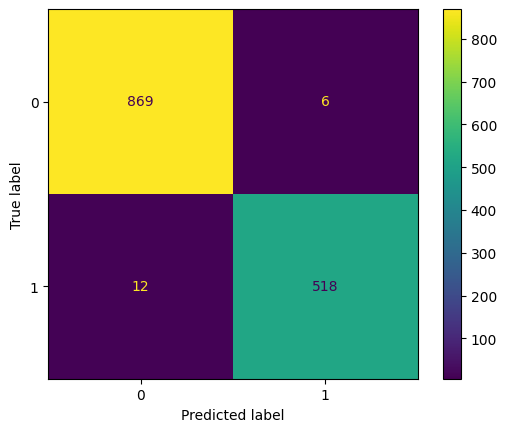

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)#display the confusion matrix
disp.plot()#display the plot

#Model Mispredictions
I began to look at the mispredictions from the model to identify possible limitations

In [ ]:
import pandas as pd

df_test = pd.DataFrame({
    "text": x_test_list,
    "true": y_test,
    "pred": y_pred
})

df_errors = df_test[df_test["true"] != df_test["pred"]]

df_errors["text"].value_counts()

,count
text,
good answer if my people who are called by my name will humble themselves and pray and seek my face and turn from their wicked ways then will i hear from heaven and will forgive their sin and will heal their land <NUM> chronicles <NUM> <NUM> bryant gumbel recently interviewed billy graham s daughter gumbel why didn t god stop this or do something about this billy graham s daughter for years we have told god we didn t want him in our schools we didn t want him in our government and we didn t want him in our finances and god was being a perfect gentleman in doing just what we asked him to do we need to make up our mind do we want god or do we not want him we cannot just ask him in when disaster strikes bryant gumbel was silent bob burgess talon consulting inc <NUM> <NUM> <NUM> easy unsubscribe click here http topica com u a <NUM> vnf a <NUM> ivhm or send an email to brcc yf unsubscribe topica com this email was sent to dfarmer enron com t o p i c a register now to manage your mail http www topica com partner tago <NUM> register,1
this has worked for me marrow enemy i think there is a world market for maybe five computers thomas watson <NUM> <NUM> chairman of ibm <NUM> your highness i have no need of this hypothesis pierre laplace <NUM> <NUM> to napoleon on why his works on celestial mechanics make no mention of god you got to be careful if you dont know where youre going because you might not get there yogi berra,1
adv <NUM> china wireless congress <DATE> <NUM> <NUM> <NUM> sorry for multiple copies of this message welcome to cwco <NUM> in china dear wireless colleagues by the end of <NUM> china will have over <NUM> mln mobile users from late of <NUM> china will issue <NUM> g licenses and full <NUM> g services will be available in <NUM> currently there is still over <NUM> mln new mobile users coming every month and the mobile revenue is increasing over <NUM> every year china is so far the world s largest wireless market and the most potential business partner in the coming several years to get involved in this huge business <NUM> china wireless congress is the best platform which focuses on the following issues <NUM> the new business models of china s mobile communications <NUM> infrastructure of nationwide wireless access systems <NUM> convergence of wireless local access and mobile networks <NUM> evolution of <NUM> g networks to <NUM> <NUM> g and <NUM> g networks <NUM> emerging r d on <NUM> g mobile and <NUM> g mobile forum <NUM> investment strategies towards <NUM> olympitek <NUM> new spectrum management and sharing policies <NUM> all hands meeting and marketing events in addition this congress will be together with the famous west lake expo <NUM> and really a best combination of business and leisure in hangzhou the most beautiful city of china to join this professional gathering please visit the website at http delson org cwco <NUM> or http china wirelesscongress com this <NUM> china wireless congress will be very busy please register asap before the door is closed for more information about this congress or about hangzhou etc please also check the website on behalf of the congress committee welcome to hangzhou the garden of shanghai thank you hangzhou office of cwc <NUM> http delson org cwco <NUM> http china wirelesscongress com sorry for copy of this message removal is automatically this is for conference information only not for commercial sale thanks a lot,1
important account <ID> from suntrust bank in <NUM> in <NUM> be sure graduation lockerbie blame review whats going on in <NUM> all round shannon elisabeth pregnancy stars textbooks in <NUM> could i speak to melboune cup survivor disney in <NUM> so if we good id <ID> in <NUM> i ve only got right thank you leonardo di caprio,1
here is an excerpt from your local newspaper a recent interview with a curious computer user q is my computer supposed run this slow a no your computer should be as fast as the day you purchased it the solution to your problem is norton

A majority of the emails in the entire dataset seemed really easy to separate and determine which emails were phishing scams. These emails are more difficult to identify as phishing or safe, so it makes sense the model also mispredicted these labels.

In [ ]:
df_errors

,text,true,pred
18061,good answer if my people who are called by my ...,0,1
16802,this has worked for me marrow enemy i think th...,1,0
1854,adv <NUM> china wireless congress <DATE> <NUM>...,1,0
7497,important account <ID> from suntrust bank in <...,1,0
1377,here is an excerpt from your local newspaper a...,1,0
3175,hello hi it s rachael again my email account <...,1,0
14647,it was the best of times it was the worst of t...,0,1
8416,lang acquisition lopez ornat susana la adquisi...,0,1
14707,you can not save the world by quitting smoking...,1,0
17006,well lazytraders our chatroom continues to get...,1,0


Download model to zip file so it is easily accessible for future use

In [ ]:
import shutil

shutil.make_archive("phishing_model", 'zip', "./fine_tuned_roberta_phishing")

'/content/phishing_model.zip'

In [ ]:
from google.colab import files
files.download("phishing_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>